<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/AdStock%26Saturation-Effect/Effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

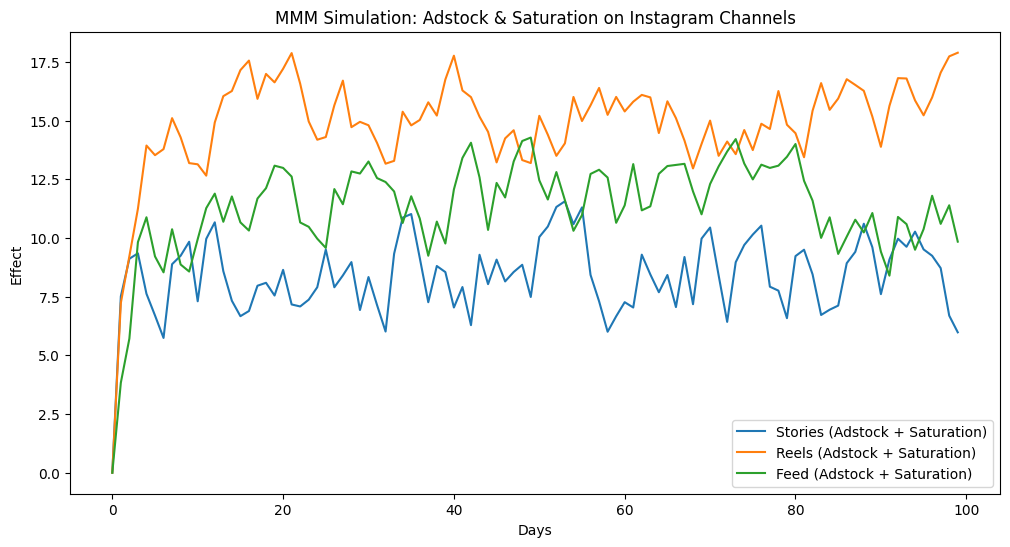

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adstock transformation function
def adstock(series, decay):
    adstocked = np.zeros_like(series)
    for i in range(1, len(series)):
        adstocked[i] = series[i] + decay * adstocked[i - 1]
    return adstocked

# Saturation function (Diminishing returns)
def saturation_effect(spend, alpha=0.5, beta=0.7):
    return alpha * (spend ** beta)

# Simulate ad spend data for three Instagram channels
np.random.seed(42)
days = 100
instagram_spend = {
    "Stories": np.random.uniform(10, 50, days),
    "Reels": np.random.uniform(20, 60, days),
    "Feed": np.random.uniform(15, 55, days)
}

# Define decay factors for Adstock effect
decay_factors = {"Stories": 0.5, "Reels": 0.7, "Feed": 0.6}

# Apply Adstock and saturation
results = {}
for channel, spend in instagram_spend.items():
    adstocked_spend = adstock(spend, decay_factors[channel])
    saturated_spend = saturation_effect(adstocked_spend)
    results[channel] = saturated_spend

# Convert to DataFrame for visualization
df = pd.DataFrame(results)

# Plot the results
plt.figure(figsize=(12, 6))
for channel in df.columns:
    plt.plot(df[channel], label=f"{channel} (Adstock + Saturation)")
plt.xlabel("Days")
plt.ylabel("Effect")
plt.title("MMM Simulation: Adstock & Saturation on Instagram Channels")
plt.legend()
plt.show()


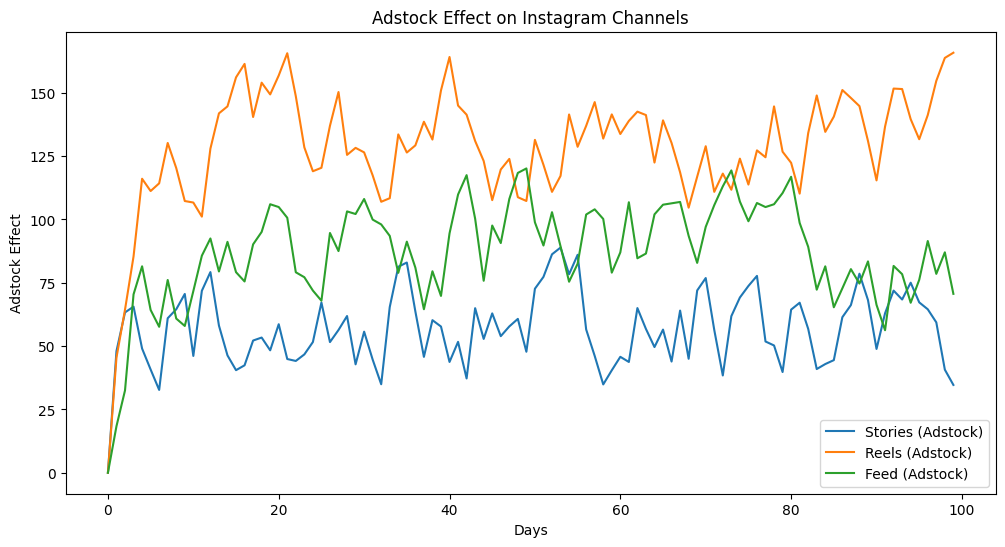

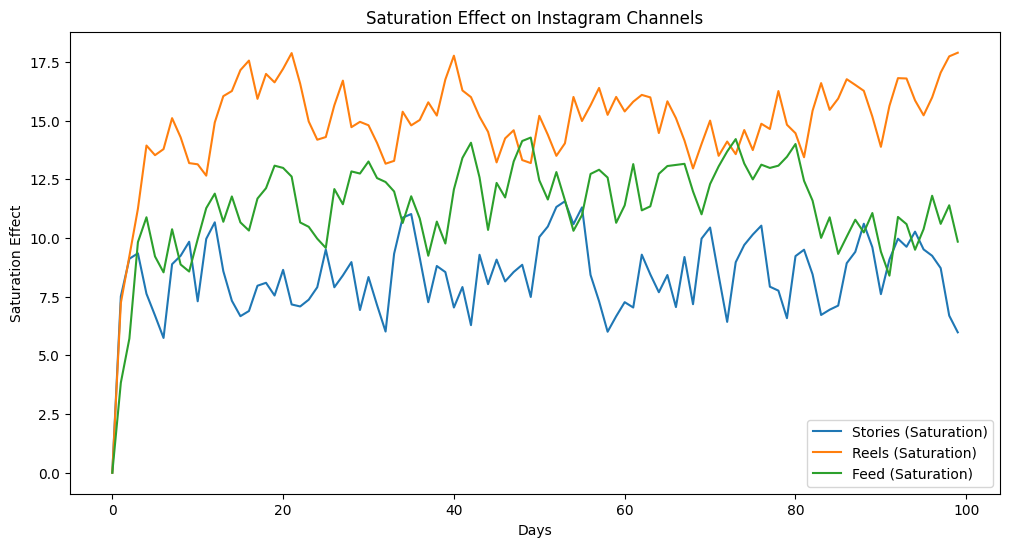

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adstock transformation function
def adstock(series, decay):
    adstocked = np.zeros_like(series)
    for i in range(1, len(series)):
        adstocked[i] = series[i] + decay * adstocked[i - 1]
    return adstocked

# Saturation function (Diminishing returns)
def saturation_effect(spend, alpha=0.5, beta=0.7):
    return alpha * (spend ** beta)

# Simulate ad spend data for three Instagram channels
np.random.seed(42)
days = 100
instagram_spend = {
    "Stories": np.random.uniform(10, 50, days),
    "Reels": np.random.uniform(20, 60, days),
    "Feed": np.random.uniform(15, 55, days)
}

# Define decay factors for Adstock effect
decay_factors = {"Stories": 0.5, "Reels": 0.7, "Feed": 0.6}

# Store results separately
adstock_results = {}
saturation_results = {}

for channel, spend in instagram_spend.items():
    adstocked_spend = adstock(spend, decay_factors[channel])
    saturated_spend = saturation_effect(adstocked_spend)

    adstock_results[channel] = adstocked_spend
    saturation_results[channel] = saturated_spend

# Convert to DataFrame for visualization
df_adstock = pd.DataFrame(adstock_results)
df_saturation = pd.DataFrame(saturation_results)

# Plot Adstock Effect
plt.figure(figsize=(12, 6))
for channel in df_adstock.columns:
    plt.plot(df_adstock[channel], label=f"{channel} (Adstock)")
plt.xlabel("Days")
plt.ylabel("Adstock Effect")
plt.title("Adstock Effect on Instagram Channels")
plt.legend()
plt.show()

# Plot Saturation Effect
plt.figure(figsize=(12, 6))
for channel in df_saturation.columns:
    plt.plot(df_saturation[channel], label=f"{channel} (Saturation)")
plt.xlabel("Days")
plt.ylabel("Saturation Effect")
plt.title("Saturation Effect on Instagram Channels")
plt.legend()
plt.show()



===== Logistic Regression Results =====
Accuracy Score: 0.837157376039421

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82     11675
           1       0.85      0.85      0.85     14301

    accuracy                           0.84     25976
   macro avg       0.84      0.84      0.84     25976
weighted avg       0.84      0.84      0.84     25976


Confusion Matrix:
 [[ 9581  2094]
 [ 2136 12165]]
Optimization terminated successfully.
         Current function value: 0.385852
         Iterations 7

===== Logistic Regression Analysis Table (Feature Importance & P-values) =====

                           Logit Regression Results                           
Dep. Variable:           satisfaction   No. Observations:               129880
Model:                          Logit   Df Residuals:                   129857
Method:                           MLE   Df Model:                           22
Date:                We

<ipython-input-5-c6030f9af91c>:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=coef_table["Feature"], x=coef_table["Odds Ratio"], palette="coolwarm")


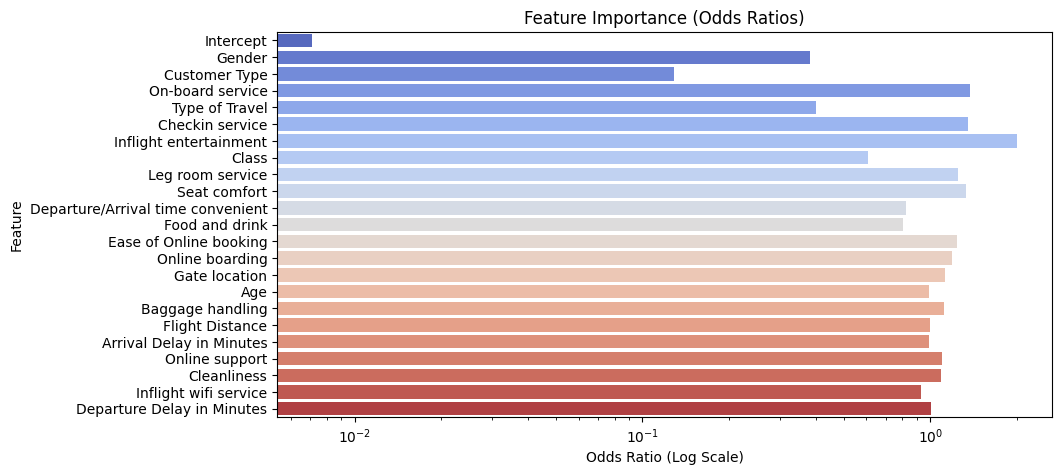


===== SHAP Analysis Results =====

Feature Importance (Mean Absolute SHAP Values):
                               Feature  Mean SHAP Value
11              Inflight wifi service         0.802901
1                              Gender         0.609119
0                        satisfaction         0.481284
3                                 Age         0.395014
14             Ease of Online booking         0.345109
6                     Flight Distance         0.336628
17                   Baggage handling         0.310938
4                      Type of Travel         0.284342
8   Departure/Arrival time convenient         0.267069
7                        Seat comfort         0.266557
15                   On-board service         0.254385
13                     Online support         0.238165
19                        Cleanliness         0.189230
21         Departure Delay in Minutes         0.158384
9                      Food and drink         0.137142
16                   Leg room servi

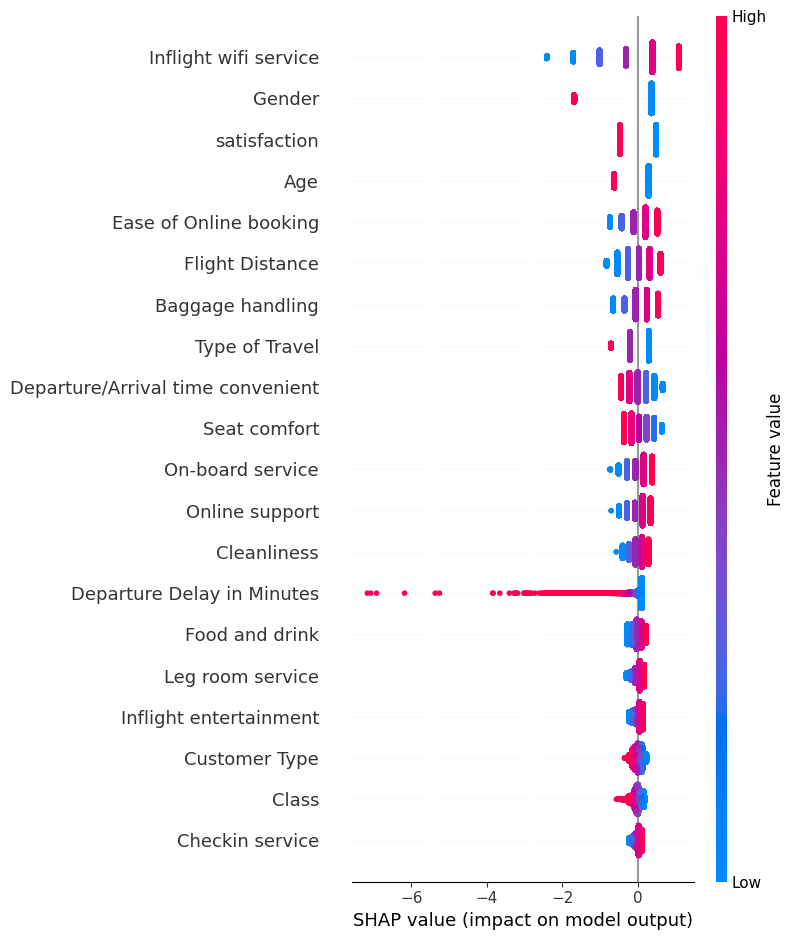

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("Invistico_Airline.csv")


# --- Data Preprocessing ---
label_encoders = {}
categorical_columns = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Encode categorical values
    label_encoders[col] = le  # Store encoder for future reference

df.fillna(df.median(), inplace=True)  # Fill missing values

# Define Features (X) and Target Variable (y)
X = df.drop(columns=["satisfaction"])
y = df["satisfaction"]

# Add constant term for statsmodels logistic regression
X_sm = sm.add_constant(X)

# Split dataset into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Logistic Regression using Scikit-Learn ---
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predict on Test Data
y_pred = log_reg.predict(X_test)

# --- Model Evaluation ---
print("\n===== Logistic Regression Results =====")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --- Logistic Regression using Statsmodels (Feature Importance with P-values) ---
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit()

# Print Summary Table (Coefficients & P-values)
print("\n===== Logistic Regression Analysis Table (Feature Importance & P-values) =====\n")
print(result.summary())

# Extract Coefficients, P-values, and Odds Ratios
coef_table = pd.DataFrame({
    "Feature": ["Intercept"] + list(X.columns),
    "Coefficient": result.params.values,
    "P-Value": result.pvalues.values,
    "Odds Ratio": np.exp(result.params.values)
}).sort_values(by="P-Value")

print("\n===== Feature Importance Table =====\n", coef_table)

# --- Feature Importance Visualization (Odds Ratios) ---
plt.figure(figsize=(10, 5))
sns.barplot(y=coef_table["Feature"], x=coef_table["Odds Ratio"], palette="coolwarm")
plt.xscale("log")
plt.xlabel("Odds Ratio (Log Scale)")
plt.ylabel("Feature")
plt.title("Feature Importance (Odds Ratios)")
plt.show()

# --- SHAP Analysis ---
print("\n===== SHAP Analysis Results =====")
explainer = shap.Explainer(log_reg, X_train)
shap_values = explainer(X_test)

# Print Mean Absolute SHAP Values
shap_importance = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Mean SHAP Value": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="Mean SHAP Value", ascending=False)

print("\nFeature Importance (Mean Absolute SHAP Values):\n", shap_importance)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=df.columns[:-1])
